In [2]:
from pathlib import Path
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("marine_debris_classifier.keras")

print("Model Loaded sucessfuly")

Model Loaded sucessfuly


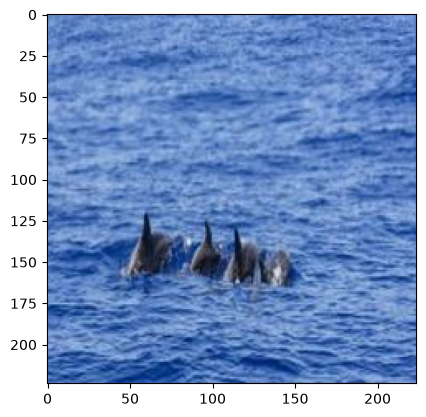

In [ ]:
PROJECT_ROOT = Path.cwd().parent
IMG_PATH = PROJECT_ROOT / "data" / "testing" / "Marine_Life" / "marine_test_1302.jpg"

img = image.load_img(IMG_PATH, target_size =(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction: Marine Life
Confidenc: 99.82%


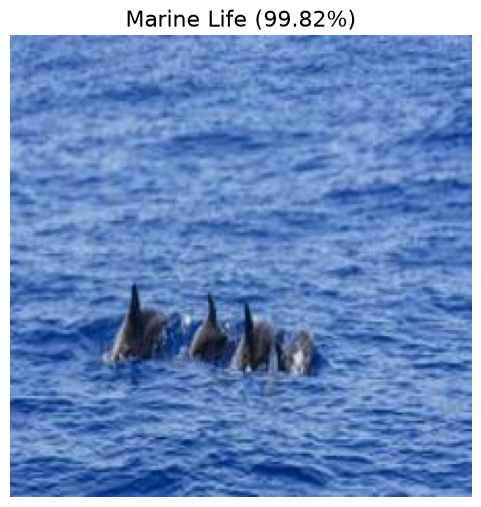

In [10]:
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)
prediction = model.predict(img_array)
#{'Marine_Life': 0, 'Plastic': 1}
prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    label = "Plastic"
    confidence = prediction * 100
else:
    label = "Marine Life"
    confidence = (1 - prediction) * 100
print(f"Prediction: {label}")
print(f"Confidenc: {confidence:.2f}%")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f}%)", fontsize=16)
plt.axis("off")
plt.show()